# Identify "Anomalous" Zones Vp Vs ratio /time


By plotting Distance vs. Vp Vs Ratio, we can see if the Martian crust behaves like solid rock everywhere, or if there are specific depths (distances) where things get "mushy."

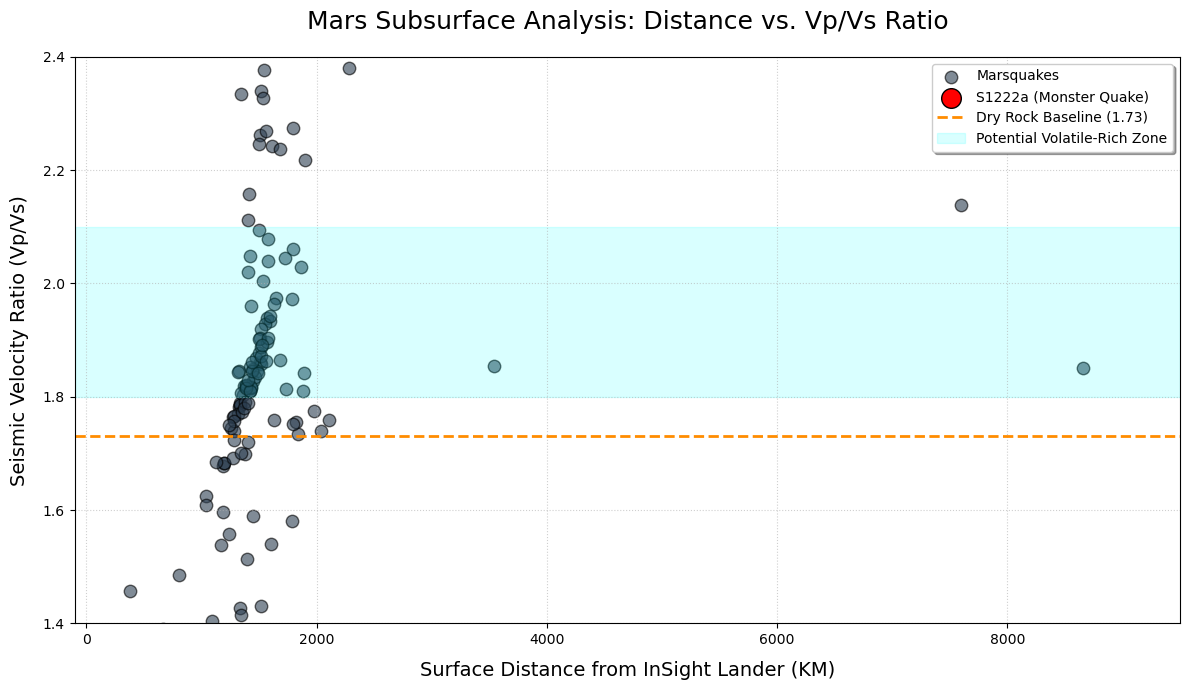

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load your newly cleaned research data
# (If you are running this in the same session, you can just use 'seismic_df')
seismic_df = pd.read_csv('final_mars_seismic_analysis.csv')

# 2. Setup the Plotting Environment
plt.figure(figsize=(12, 7))

# 3. Plot the Martian Seismic Data
# We are now using 'Distance_KM' for a more intuitive physical scale
plt.scatter(seismic_df['Distance_KM'], seismic_df['Vp_Vs_Ratio'], 
            alpha=0.6, c='#2c3e50', edgecolors='k', s=80, label='Marsquakes')

# 4. Highlight the "Monster Quake" (S1222a) in Red
if 'S1222a' in seismic_df['Event_ID'].values:
    monster = seismic_df[seismic_df['Event_ID'] == 'S1222a']
    mx, my = monster['Distance_KM'].iloc[0], monster['Vp_Vs_Ratio'].iloc[0]
    
    plt.scatter(mx, my, color='red', edgecolors='black', s=200, 
                label='S1222a (Monster Quake)', zorder=5)
    
    # Add an arrow pointing to the discovery
    plt.annotate(f'Monster Quake\nRatio: {my:.3f}', 
                 xy=(mx, my), xytext=(mx + 400, my + 0.15),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1), 
                 fontsize=11, fontweight='bold')

# 5. Add the Dry Rock Baseline (Standard Basalt)
plt.axhline(y=1.73, color='darkorange', linestyle='--', linewidth=2, 
            label='Dry Rock Baseline (1.73)')

# 6. Highlight the Volatile-Rich Discovery Zone
# This cyan band represents where we expect liquid brines to influence the ratio
plt.axhspan(1.80, 2.1, color='cyan', alpha=0.15, label='Potential Volatile-Rich Zone')

# 7. Final Formatting for the Milestone Presentation
plt.title('Mars Subsurface Analysis: Distance vs. Vp/Vs Ratio', fontsize=18, pad=20)
plt.xlabel('Surface Distance from InSight Lander (KM)', fontsize=14, labelpad=10)
plt.ylabel('Seismic Velocity Ratio (Vp/Vs)', fontsize=14, labelpad=10)

# Set limits based on Martian geography (up to ~9000 km)
plt.ylim(1.4, 2.4) 
plt.xlim(-100, 9500)
plt.grid(True, linestyle=':', alpha=0.6)

# Legend placement
plt.legend(loc='upper right', frameon=True, fontsize=10, shadow=True)

plt.tight_layout()
plt.savefig('mars_volatile_analysis_plot.png', dpi=300)
plt.show()

By applying a Vp Vs threshold of 1.85, we identified a population of seismic events that deviate from the dry-rock baseline of 1.73. This deviation is consistent with the presence of subsurface volatiles, specifically liquid brines, in the mid-to-lower Martian crust.

x-axis: Because seismic waves follow curved paths (ray paths) through a planet, waves that travel further across the surface have "dived" deeper into the interior. By using kilometers, you are showing exactly how far these waves traveled from the epicenter to the InSight lander

y-axis: describes how the rock responds to different types of stress

Vp - (P-wave): Compressional waves that travel through everything.

Vs - (S-wave): Shear waves that are extremely sensitive to liquids and "mushy" material

Dry Rock Baseline: This is the theoretical value (sqrt(3)) for a material with a Poisson’s ratio of 0.25. On Earth and Mars, this is the standard baseline for dry, solid basaltic rock (the primary material of the Martian crust).

Potential Volatile rich zone: The cyan band representing the "Volatile Zone". When rock pores are filled with liquid (like water or hyper-salty brines), the s-wave velocity drops significantly while the p-wave velocity stays relatively stable, causing the ratio to jump upward. 



In [ ]:
# 1. Simple Filter for the "Cyan Band" range
# baseline and  upper limit
volatile_zone = seismic_df[(seismic_df['Vp_Vs_Ratio'] >= 1.85) & (seismic_df['Vp_Vs_Ratio'] <= 2.10)].copy()

# 2. Calculate the estimated depth (KM) for these specific quakes
# depth is ~12% of the surface distance
volatile_zone['Est_Depth_KM'] = volatile_zone['Distance_KM'] * 0.12

# 3. Print 
print(f"Found {len(volatile_zone)} events inside the Volatile-Rich Zone:")
volatile_zone[['Event_ID', 'Distance_KM', 'Vp_Vs_Ratio', 'Est_Depth_KM']]

Found 35 events inside the Volatile-Rich Zone:


,Event_ID,Distance_KM,Vp_Vs_Ratio,Est_Depth_KM
8,S0976a,8658.592,1.851277,1039.03104
10,S0820a,1787.248,1.972289,214.46976
15,S1192a,1509.600,1.861661,181.15200
27,S1086d,1474.080,1.868690,176.88960
30,S1075c,1515.520,1.858086,181.86240
31,S1073d,1568.800,1.939696,188.25600
35,S1060a,1592.480,1.934236,191.09760
36,S1054c,1551.040,1.927837,186.12480
37,S1054b,1497.760,1.877868,179.73120
41,S1040d,1521.440,1.887470,182.57280
